In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

import pickle


Load All Landmark Data

In [2]:
data_dir = "static_landmarks"

X = []
y = []

labels = sorted(os.listdir(data_dir))

for label in labels:
    label_path = os.path.join(data_dir, label)
    
    if not os.path.isdir(label_path):
        continue
    
    for file in os.listdir(label_path):
        file_path = os.path.join(label_path, file)
        
        landmarks = np.load(file_path)
        X.append(landmarks)
        y.append(label)

X = np.array(X)
y = np.array(y)

print("Data shape:", X.shape)
print("Labels shape:", y.shape)


Data shape: (10581, 63)
Labels shape: (10581,)


Encode Labels

In [3]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Classes:", le.classes_)

np.save("static_label_classes.npy", le.classes_)


Classes: ['A' 'B' 'C' 'D' 'E' 'F' 'G' 'H' 'I' 'J' 'K' 'L' 'M' 'N' 'O' 'P' 'Q' 'R'
 'S' 'T' 'U' 'V' 'W' 'X' 'Y' 'Z']


In [4]:
os.makedirs("models", exist_ok=True)

with open("models/label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)

print("✅ Encoder saved correctly.")


✅ Encoder saved correctly.


Train/Test Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (8464, 63)
Test shape: (2117, 63)


Build Model

In [6]:
from keras.models import Sequential
from keras.layers import Input, Dense, Dropout

num_classes = len(le.classes_)

model = Sequential([
    Input(shape=(63,)),      # <-- preferred way
    Dense(128, activation='relu', input_shape=(63,)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


c:\Projects\signia-fsl-recognition\fsl39\lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Train Model

In [7]:
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_test, y_test)
)


Epoch 1/30
265/265 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - accuracy: 0.1935 - loss: 2.8073 - val_accuracy: 0.7232 - val_loss: 1.2737
Epoch 2/30
265/265 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5522 - loss: 1.3625 - val_accuracy: 0.8342 - val_loss: 0.7053
Epoch 3/30
265/265 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6858 - loss: 0.9098 - val_accuracy: 0.8583 - val_loss: 0.4971
Epoch 4/30
265/265 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.7659 - loss: 0.7015 - val_accuracy: 0.8781 - val_loss: 0.4081
Epoch 5/30
265/265 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7940 - loss: 0.5910 - val_accuracy: 0.8975 - val_loss: 0.3503
Epoch 6/30
265/265 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8140 - loss: 0.5362 - val_accuracy: 0.9150 - val_loss: 0.3028
Epoch 7/30
265/265 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8419 - loss: 0.4794 - val_accuracy: 0.9173 - val_loss: 0.2851
Epoch 8/30
265/265 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8373 - loss: 0.4599 - val_accuracy:

Evaluate Model

In [8]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)


67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9691 - loss: 0.1107
Test Accuracy: 0.9782711267471313


Plot Accuracy Graph (Important for Defense)

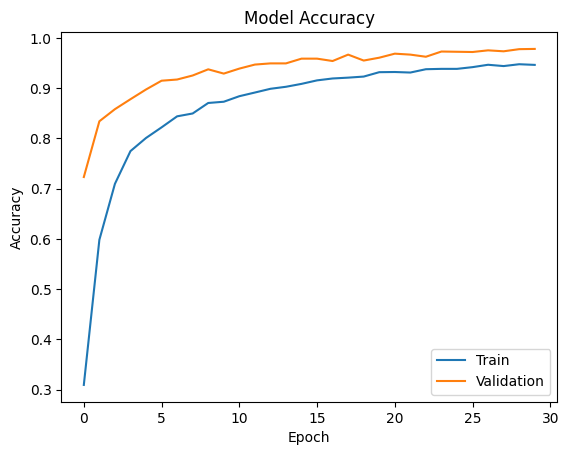

In [9]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()


Confusion Matrix (Very Important for Panel)

In [10]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)

print(cm)


67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
[[76  0  0  0  0  0  0  0  0  0  0  0  0  0  1  0  0  0  0  0  0  0  0  0
   0  0]
 [ 0 89  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0]
 [ 0  0 71  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0]
 [ 0  0  0 88  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0]
 [ 0  0  0  0 84  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0]
 [ 0  3  0  0  0 87  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0]
 [ 0  0  0  0  0  0 89  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0]
 [ 0  0  0  0  0  0  0 89  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0]
 [ 2  0  0  0  0  0  0  0 87  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0]
 [ 0  0  0  0  0  0  0  0  0 89  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0]
 [ 0  0  0  0  0  0  0  0  0  0 89  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0]
 [ 0  0  1  0  0  0  0  0  0  0  0 82  0  0  0  

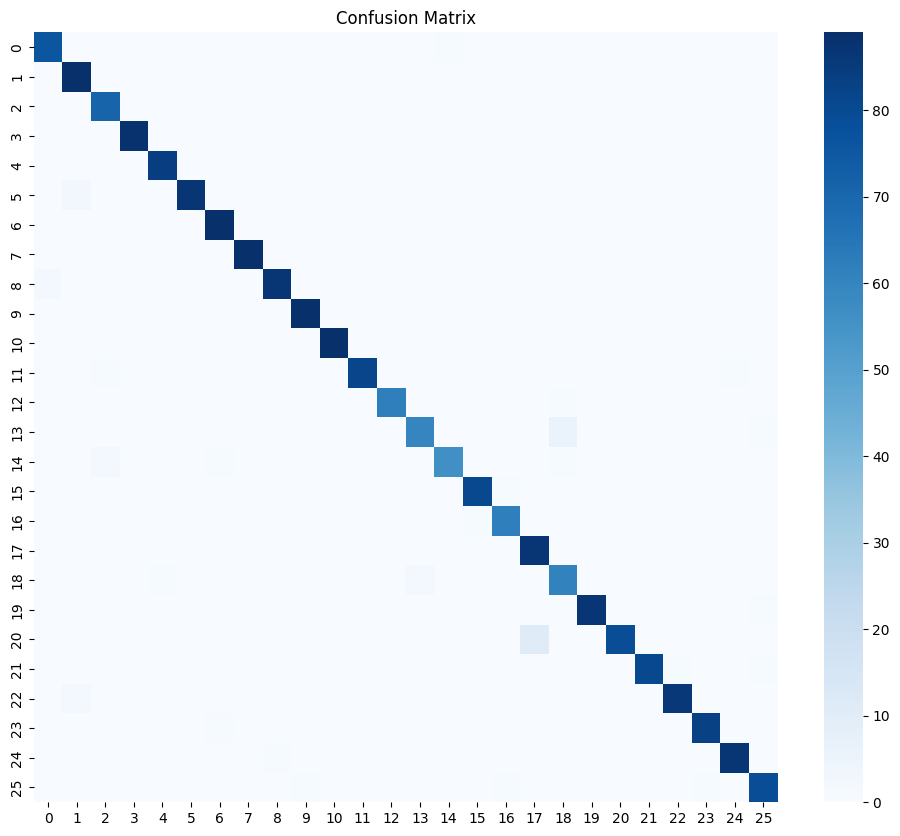

In [11]:
import seaborn as sns

plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=False, cmap="Blues")
plt.title("Confusion Matrix")
plt.show()


Classification Report

In [12]:
print(classification_report(y_test, y_pred_classes, target_names=le.classes_))


              precision    recall  f1-score   support

           A       0.97      0.99      0.98        77
           B       0.95      1.00      0.97        89
           C       0.96      1.00      0.98        71
           D       1.00      1.00      1.00        88
           E       0.99      1.00      0.99        84
           F       1.00      0.97      0.98        90
           G       0.98      1.00      0.99        89
           H       1.00      1.00      1.00        89
           I       0.99      0.98      0.98        89
           J       0.99      1.00      0.99        89
           K       1.00      1.00      1.00        89
           L       1.00      0.98      0.99        84
           M       1.00      0.98      0.99        63
           N       0.97      0.90      0.93        67
           O       0.98      0.93      0.96        60
           P       0.99      0.99      0.99        82
           Q       0.97      0.98      0.98        63
           R       0.89    

Save Model

In [13]:
model.save("models/static_fsl_model.keras")

print(model.input_shape)


(None, 63)


In [15]:
print("Train Min:", X_train.min())
print("Train Max:", X_train.max())


Train Min: -1.0
Train Max: 1.0


In [17]:
preprocess_config = {'scale_mode': 'bbox'}  # or 'max_dist' or 'none', whatever you used in training

import pickle
with open("models/preprocess_config.pkl", "wb") as f:
    pickle.dump(preprocess_config, f)
